<a href="https://colab.research.google.com/github/Sadith14/ALGORITMOS-DE-ENJAMBRE-EN-EL-APRENDIZAJE-M-QUINA/blob/main/NN_training_without_backpropagation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PASO 1: CARGA Y PREPROCESAMIENTO
Dataset cargado correctamente
Muestras : 8124
Columnas : 23

Distribución de clases:
class
e    4208
p    3916
Name: count, dtype: int64

División de datos:
Train : 6499
Test  : 1625

PASO 2: ARQUITECTURA DE LA RED NEURONAL

Arquitectura:

22 → 16 → 8 → 1

Entrada   : 22 neuronas
Oculta 1  : 16 neuronas (ReLU)
Oculta 2  : 8 neuronas (ReLU)
Salida    : 1 neurona (Sigmoid)

Parámetros totales: 513

PASO 3: FUNCIÓN FITNESS

Fitness = 0.7 * Binary Cross Entropy + 0.3 * Error Rate

Objetivo:
Minimizar Fitness


PASO 4: INICIALIZACIÓN DEL ENJAMBRE

Partículas       : 50
Iteraciones máx. : 200
Inercia inicial  : 0.9
Inercia final    : 0.4
c1 cognitivo     : 2.0
c2 social        : 2.0
Velocidad máx.   : 0.5

Fitness inicial global: 0.577657

PASO 5: EVOLUCIÓN DEL PSO
 Iter |    Fitness |    Train |     Test
---------------------------------------------
    1 |    0.45285 |   0.7887 |   0.8031
   20 |    0.25612 |   0.8861 |   0.8868
   40 |    0.21556 |   0.912

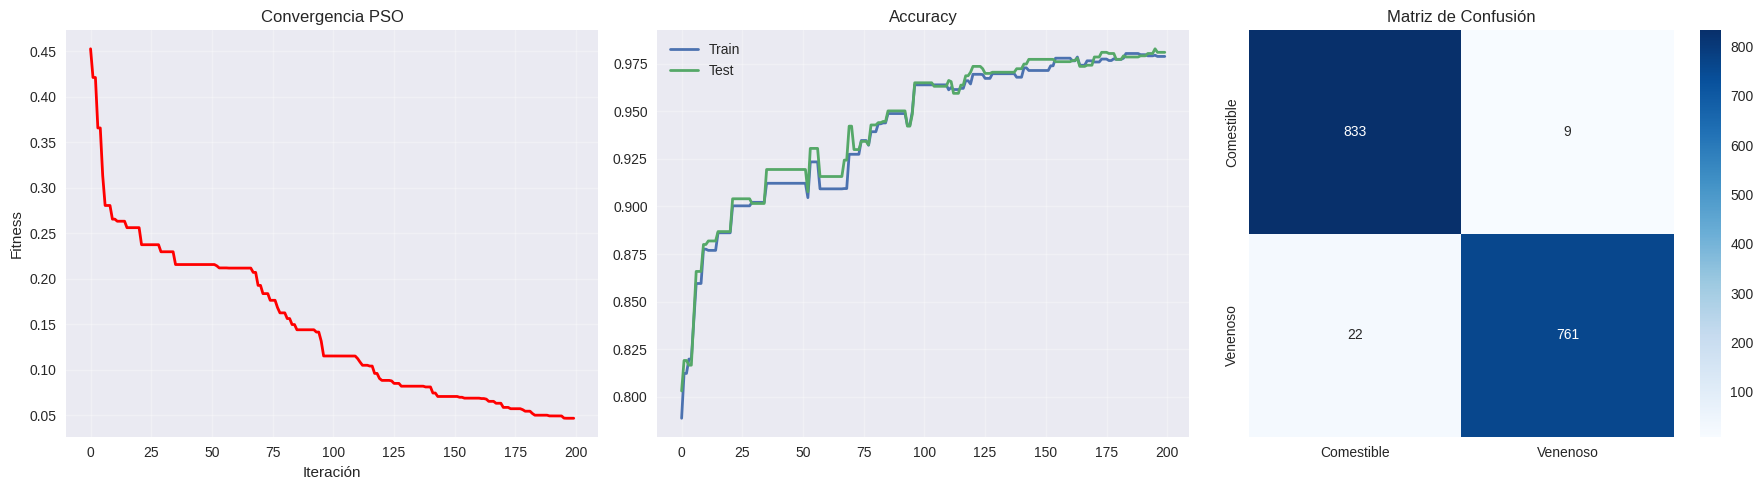


Proceso finalizado correctamente ✓


In [ ]:
# ================================================================
# PSO + RED NEURONAL (SIN BACKPROPAGATION)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
np.random.seed(42)

# ================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO
# ================================================================
print("="*65)
print("PASO 1: CARGA Y PREPROCESAMIENTO")
print("="*65)

df = pd.read_csv("mushrooms.csv")

print(f"Dataset cargado correctamente")
print(f"Muestras : {df.shape[0]}")
print(f"Columnas : {df.shape[1]}")

print("\nDistribución de clases:")
print(df["class"].value_counts())

# Target
le_y = LabelEncoder()
y = le_y.fit_transform(df["class"]).reshape(-1,1)

# Features
X_df = df.drop("class", axis=1)

for col in X_df.columns:
    le = LabelEncoder()
    X_df[col] = le.fit_transform(X_df[col])

X = X_df.values.astype(float)

# Normalización [0,1]
X = (X - X.min(axis=0)) / (X.max(axis=0)-X.min(axis=0)+1e-8)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDivisión de datos:")
print(f"Train : {X_train.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

# ================================================================
# PASO 2: ARQUITECTURA DE LA RED
# ================================================================
print("\n" + "="*65)
print("PASO 2: ARQUITECTURA DE LA RED NEURONAL")
print("="*65)

IN = X_train.shape[1]
H1 = 16
H2 = 8
OUT = 1

print(f"""
Arquitectura:

{IN} → {H1} → {H2} → {OUT}

Entrada   : {IN} neuronas
Oculta 1  : {H1} neuronas (ReLU)
Oculta 2  : {H2} neuronas (ReLU)
Salida    : {OUT} neurona (Sigmoid)
""")

shapes = [
    (IN,H1),(H1,),
    (H1,H2),(H2,),
    (H2,OUT),(OUT,)
]

DIM = sum(np.prod(s) for s in shapes)

print(f"Parámetros totales: {DIM}")

# ================================================================
# FUNCIONES AUXILIARES
# ================================================================
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1/(1+np.exp(-np.clip(x,-500,500)))

def decode(particle):
    params = []
    idx = 0
    for s in shapes:
        n = np.prod(s)
        params.append(particle[idx:idx+n].reshape(s))
        idx += n
    return params

def forward(X, particle):
    W1,b1,W2,b2,W3,b3 = decode(particle)

    z1 = relu(X @ W1 + b1)
    z2 = relu(z1 @ W2 + b2)
    out = sigmoid(z2 @ W3 + b3)

    return out

# ================================================================
# PASO 3: FUNCIÓN FITNESS
# ================================================================
print("\n" + "="*65)
print("PASO 3: FUNCIÓN FITNESS")
print("="*65)

print("""
Fitness = 0.7 * Binary Cross Entropy + 0.3 * Error Rate

Objetivo:
Minimizar Fitness
""")

def fitness(particle):
    pred = np.clip(forward(X_train, particle),1e-8,1-1e-8)

    bce = -np.mean(
        y_train*np.log(pred)+(1-y_train)*np.log(1-pred)
    )

    err = np.mean((pred>=0.5)!=y_train)

    return 0.7*bce + 0.3*err

# ================================================================
# PASO 4: INICIALIZACIÓN DEL ENJAMBRE
# ================================================================
print("\n" + "="*65)
print("PASO 4: INICIALIZACIÓN DEL ENJAMBRE")
print("="*65)

N = 50
T = 200
W0 = 0.9
WF = 0.4
C1 = 2.0
C2 = 2.0
VM = 0.5
THR = 0.01

print(f"""
Partículas       : {N}
Iteraciones máx. : {T}
Inercia inicial  : {W0}
Inercia final    : {WF}
c1 cognitivo     : {C1}
c2 social        : {C2}
Velocidad máx.   : {VM}
""")

pos = np.random.uniform(-2,2,(N,DIM))
vel = np.random.uniform(-0.1,0.1,(N,DIM))

pb_pos = pos.copy()
pb_fit = np.array([fitness(p) for p in pos])

gb_idx = np.argmin(pb_fit)
gb_pos = pb_pos[gb_idx].copy()
gb_fit = pb_fit[gb_idx]

print(f"Fitness inicial global: {gb_fit:.6f}")

# ================================================================
# PASO 5: EVOLUCIÓN DEL PSO
# ================================================================
print("\n" + "="*65)
print("PASO 5: EVOLUCIÓN DEL PSO")
print("="*65)

print(f"{'Iter':>5} | {'Fitness':>10} | {'Train':>8} | {'Test':>8}")
print("-"*45)

hist_fit = []
hist_train = []
hist_test = []

t0 = time.time()

for t in range(T):

    w = W0 - (W0-WF)*(t/T)

    for i in range(N):

        r1 = np.random.rand(DIM)
        r2 = np.random.rand(DIM)

        vel[i] = (
            w*vel[i]
            + C1*r1*(pb_pos[i]-pos[i])
            + C2*r2*(gb_pos-pos[i])
        )

        vel[i] = np.clip(vel[i],-VM,VM)

        pos[i] += vel[i]

        pos[i] = np.clip(pos[i],-2,2)

        f = fitness(pos[i])

        if f < pb_fit[i]:
            pb_fit[i] = f
            pb_pos[i] = pos[i].copy()

            if f < gb_fit:
                gb_fit = f
                gb_pos = pos[i].copy()

    # métricas
    pred_train = (forward(X_train,gb_pos)>=0.5).astype(int)
    pred_test  = (forward(X_test,gb_pos)>=0.5).astype(int)

    acc_train = accuracy_score(y_train,pred_train)
    acc_test  = accuracy_score(y_test,pred_test)

    hist_fit.append(gb_fit)
    hist_train.append(acc_train)
    hist_test.append(acc_test)

    if (t+1)%20==0 or t==0:
        print(f"{t+1:5d} | {gb_fit:10.5f} | {acc_train:8.4f} | {acc_test:8.4f}")

    if gb_fit < THR:
        print(f"\nConvergencia alcanzada en iteración {t+1}")
        break

# ================================================================
# PASO 6: RESULTADOS FINALES
# ================================================================
print("\n" + "="*65)
print("PASO 6: RESULTADOS FINALES")
print("="*65)

final_train = (forward(X_train,gb_pos)>=0.5).astype(int)
final_test  = (forward(X_test,gb_pos)>=0.5).astype(int)

acc_tr = accuracy_score(y_train,final_train)
acc_te = accuracy_score(y_test,final_test)

print(f"""
Tiempo total       : {time.time()-t0:.2f} segundos
Fitness final      : {gb_fit:.6f}
Accuracy Train     : {acc_tr*100:.2f}%
Accuracy Test      : {acc_te*100:.2f}%
""")

print("Reporte de clasificación TEST:\n")
print(classification_report(
    y_test,
    final_test,
    target_names=["Comestible","Venenoso"]
))
# ================================================================
# PASO 6.5: MEJORES PESOS Y BIAS ENCONTRADOS POR PSO
# ================================================================
print("\n" + "="*65)
print("PASO 6.5: MEJORES PESOS Y BIAS (gbest)")
print("="*65)

W1, b1, W2, b2, W3, b3 = decode(gb_pos)

nombres = [
    ("W1 (Entrada→Oculta1)", W1),
    ("b1 (Bias Oculta1)",    b1),
    ("W2 (Oculta1→Oculta2)", W2),
    ("b2 (Bias Oculta2)",    b2),
    ("W3 (Oculta2→Salida)",  W3),
    ("b3 (Bias Salida)",     b3),
]

for nombre, param in nombres:
    print(f"\n{'─'*55}")
    print(f"  {nombre}")
    print(f"  Shape : {param.shape}")
    print(f"  Min   : {param.min():.6f}")
    print(f"  Max   : {param.max():.6f}")
    print(f"  Media : {param.mean():.6f}")
    print(f"  Std   : {param.std():.6f}")
    print(f"\n  Valores:")
    print(np.round(param, 4))

print(f"\n{'─'*55}")
print(f"  Vector completo gbest (primeros 20 valores):")
print(np.round(gb_pos[:20], 6))
print(f"  ... ({len(gb_pos)} parámetros totales)")
# ================================================================
# PASO 7: GRÁFICAS
# ================================================================
print("="*65)
print("PASO 7: GENERANDO GRÁFICAS")
print("="*65)

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1,3,figsize=(18,5))

# Fitness
ax[0].plot(hist_fit,color="red",lw=2)
ax[0].set_title("Convergencia PSO")
ax[0].set_xlabel("Iteración")
ax[0].set_ylabel("Fitness")
ax[0].grid(True,alpha=0.3)

# Accuracy
ax[1].plot(hist_train,label="Train",lw=2)
ax[1].plot(hist_test,label="Test",lw=2)
ax[1].set_title("Accuracy")
ax[1].legend()
ax[1].grid(True,alpha=0.3)

# Matriz confusión
cm = confusion_matrix(y_test,final_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[2],
    xticklabels=["Comestible","Venenoso"],
    yticklabels=["Comestible","Venenoso"]
)

ax[2].set_title("Matriz de Confusión")

plt.tight_layout()
plt.show()

print("\nProceso finalizado correctamente ✓")